# Jeu de données de transaction  -  analyse de données clients 

Les jeux de données transactionnels sont l'un des types de données clients les plus courants accessibles à toutes les entreprises. Ces jeux de données contiennent des informations sur l'historique d'achat des clients, y compris le montant, la fréquence et la date des achats.

Notre jeu de donnée est nommé transation_dataset et est au format .csv


#### installation des librairies nécessaires

In [241]:

import pandas as pd
import numpy as np
import matplotlib as plt
%matplotlib inline

#### image illustrative

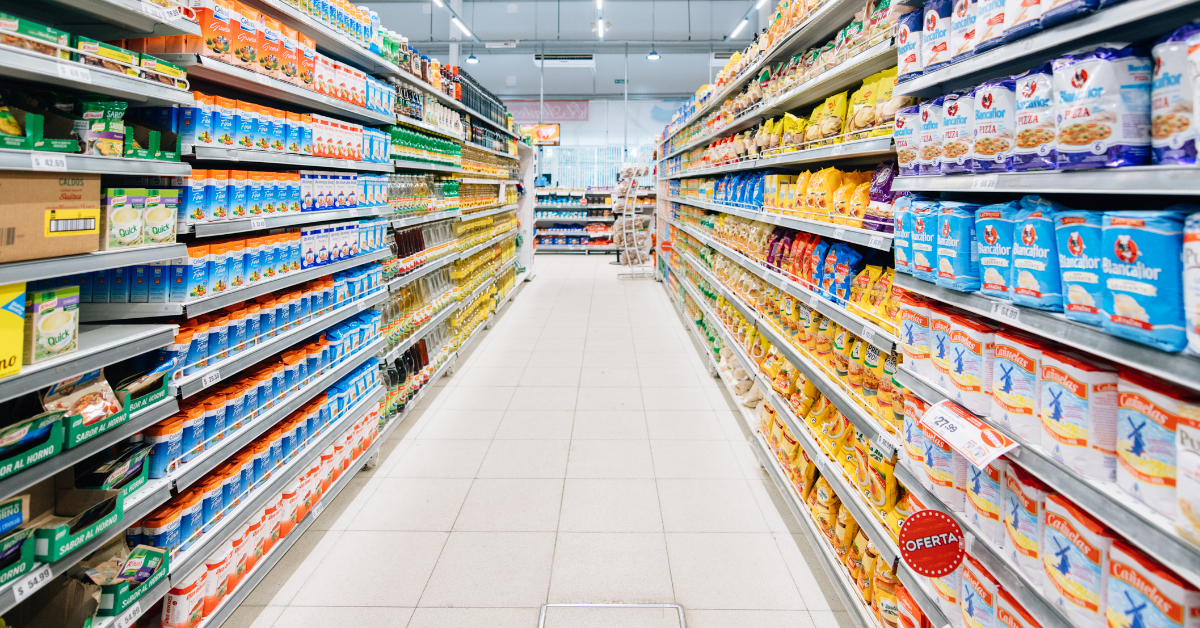

In [243]:

from IPython.display import Image, display

# Il suffit de mettre le nom du fichier si l'image est dans le même dossier
nom_image = "illustration.png"

# Affichage de l'image
display(Image(filename=nom_image))

#### importation de la base

In [245]:

transaction_df = pd.read_csv('data/transaction_dataset.csv', low_memory=False)

# aperçu des 10 preemières lignes de notre base
transaction_df.head()

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate,Country
0,17850.0,536365,15.30,12/1/2010 8:26,United Kingdom
1,17850.0,536365,20.34,12/1/2010 8:26,United Kingdom
2,17850.0,536365,22.00,12/1/2010 8:26,United Kingdom
3,17850.0,536365,20.34,12/1/2010 8:26,United Kingdom
4,17850.0,536365,20.34,12/1/2010 8:26,United Kingdom


#### les variables de notre base de données

- **CustomerID**: Identifiant unique assigné à chaque client
- **InvoiceNo**: Identifiant unique pour chaque facture
- **AmountSpent**: Montant dépensé par le client
- **InvoiceDate**: Date de la transaction
- **Country**: Nom du pays où la commande a été passée

In [247]:
# dimension de la base
transaction_df.shape

(541908, 5)

Elle comprend 5 colonnes et  541908 lignes au total

Avant toute analyse, il faut s'assurer que notre base de données est propre et que les données sont utilisables
afin de produire des analyses pertinentes et efficaces. 

Nous n'oublions pas la fameuse phrase que tous data analyste connait: GARBAGE IN, GARBAGE OUT. Si l'analyse est faite sur une base de données qui n'est pas nettoyée, dépourvue des valeurs nulles, des valeurs manquées ....etc, notre analyse sera probablement erronée.

In [250]:
# vérifions s'il y a des valeurs manquantes
transaction_df.isnull().sum()

CustomerID     135080
InvoiceNo           0
AmountSpent         0
InvoiceDate         0
Country             0
dtype: int64

On constate que notre vatiable CustomerID qui est Identifiant unique assigné à chaque client a 135080 valeurs manquante.

Cette variable n'est pas traitable car nous ne pouvons pas déviner l'ID de quel cleint a été omis. De ce fait, nous allons simplement supprimer toutes les lignes où CustomerID est nulle. 

In [252]:
# Suppression des lignes où CustomerID est nulle
transaction_df.dropna(inplace=True)

In [253]:
# vérification
transaction_df.isnull().sum()

CustomerID     0
InvoiceNo      0
AmountSpent    0
InvoiceDate    0
Country        0
dtype: int64

In [254]:
# sommaire de notre base de données pour comprendre les types de nos variables 
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406828 entries, 0 to 541907
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CustomerID   406828 non-null  float64
 1   InvoiceNo    406828 non-null  object 
 2   AmountSpent  406828 non-null  float64
 3   InvoiceDate  406828 non-null  object 
 4   Country      406828 non-null  object 
dtypes: float64(2), object(3)
memory usage: 18.6+ MB


Il y a trois colonnes dont le type de données est 'object'. Convertissons-les en types de données appropriés. Ici, CustomerID est enregistré comme un nombre flottant alors qu'il s'agit toujours d'un entier.

In [256]:
# InvoiceNo en integer
transaction_df['InvoiceNo'] = transaction_df['InvoiceNo'].astype(int)

# InvoiceDate en datetime
transaction_df['InvoiceDate'] = pd.to_datetime(transaction_df['InvoiceDate'])

# Country en string
transaction_df['Country'] = transaction_df['Country'].astype(str)

La colonne CustomerID contient actuellement des valeurs de type float bien que les données soient des nombres entiers. Convertissons également son type de données de float à entier.

In [258]:
# CustomerID en integer
transaction_df['CustomerID'] = transaction_df['CustomerID'].astype(int)

Maintenant, examinons l'en-tête du DataFrame pour vérifier que les types de données ont été assignés de manière appropriée.

In [260]:
# Looking at the first five rows
transaction_df.head()

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate,Country
0,17850,536365,15.30,2010-12-01 08:26:00,United Kingdom
1,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom
2,17850,536365,22.00,2010-12-01 08:26:00,United Kingdom
3,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom
4,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom


In [261]:
transaction_df.dtypes

CustomerID              int32
InvoiceNo               int32
AmountSpent           float64
InvoiceDate    datetime64[ns]
Country                object
dtype: object

Enfin, vérifions également si toutes les valeurs numériques du jeu de données sont correctes ou non.

In [263]:
# Getting a statistical description of the dataset
transaction_df.describe()

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate
count,406828.000000,406828.000000,406828.000000,406828
mean,15287.694552,560581.737412,20.401913,2011-07-10 16:30:54.475159296
min,12346.000000,536365.000000,-168469.600000,2010-12-01 08:26:00
25%,13953.000000,549130.000000,4.200000,2011-04-06 15:02:00
50%,15152.000000,561873.000000,11.100000,2011-07-31 11:48:00
75%,16791.000000,572065.000000,19.500000,2011-10-20 13:06:00
max,18287.000000,581587.000000,168469.600000,2011-12-09 12:50:00
std,1713.600528,13105.458755,427.592241,NaN


Nous pouvons voir que la colonne AmountSpent contient des valeurs négatives. Cependant, une telle colonne ne peut contenir que des valeurs positives supérieures à 0, car il s'agit des montants. Corrigeons cela.

On fait l'hypothèse selon laquelle, au moment de la saisie une erreur peut se glisser en mettant moins devant le montant. C'est l'hypothèse la plus probable dans notre situation 

In [265]:
# transformation en valeurs positives
transaction_df['AmountSpent'] = transaction_df['AmountSpent'].abs()

In [266]:
# Getting a statistical description of the dataset
transaction_df.describe()

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate
count,406828.000000,406828.000000,406828.000000,406828
mean,15287.694552,560581.737412,23.407303,2011-07-10 16:30:54.475159296
min,12346.000000,536365.000000,0.000000,2010-12-01 08:26:00
25%,13953.000000,549130.000000,4.680000,2011-04-06 15:02:00
50%,15152.000000,561873.000000,11.800000,2011-07-31 11:48:00
75%,16791.000000,572065.000000,19.800000,2011-10-20 13:06:00
max,18287.000000,581587.000000,168469.600000,2011-12-09 12:50:00
std,1713.600528,13105.458755,427.438254,NaN


In [267]:
# enrégistrons la base nettoyée et lu renommant en customer_dataset
transaction_df.to_csv('data/customer_dataset.csv', header=True, index=False)

Une fois la nouvelle version de la base de données sauvégardé, continuons.

## Réalisation d'une analyse client (ou : Analyse des données clients)

In [270]:
#vérifions qu'elle est bien sauvégardeée
customer_df = pd.read_csv('data/customer_dataset.csv')

In [271]:
customer_df.head(10)

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate,Country
0,17850,536365,15.30,2010-12-01 08:26:00,United Kingdom
1,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom
2,17850,536365,22.00,2010-12-01 08:26:00,United Kingdom
3,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom
4,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom
5,17850,536365,15.30,2010-12-01 08:26:00,United Kingdom
6,17850,536365,25.50,2010-12-01 08:26:00,United Kingdom
7,17850,536366,11.10,2010-12-01 08:28:00,United Kingdom
8,17850,536366,11.10,2010-12-01 08:28:00,United Kingdom
9,13047,536367,54.08,2010-12-01 08:34:00,United Kingdom


In [272]:
#sa dimension
customer_df.shape

(406828, 5)

In [273]:
#Examinons les valeurs uniques de chaque colonne  de la base
customer_df.nunique()

CustomerID      4372
InvoiceNo      22189
AmountSpent     3027
InvoiceDate    20460
Country           37
dtype: int64

Notre base de données, après premier nettoyage a des informations sur 4372 clients (correspondant à la colonne CustomerID)

In [275]:
#regroupement des clients par pays
unique_customers_per_country = customer_df.groupby('Country')[['CustomerID']].nunique()
print(unique_customers_per_country)

                      CustomerID
Country                         
Australia                      9
Austria                       11
Bahrain                        2
Belgium                       25
Brazil                         1
Canada                         4
Channel Islands                9
Cyprus                         8
Czech Republic                 1
Denmark                        9
EIRE                           3
European Community             1
Finland                       12
France                        87
Germany                       95
Greece                         4
Iceland                        1
Israel                         4
Italy                         15
Japan                          8
Lebanon                        1
Lithuania                      1
Malta                          2
Netherlands                    9
Norway                        10
Poland                         6
Portugal                      19
RSA                            1
Saudi Arab

In [276]:
# nom de colonne dans unique_customers_per_country
unique_customers_per_country.columns = ['Nbr_of_customers']
unique_customers_per_country.head()

,Nbr_of_customers
Country,
Australia,9
Austria,11
Bahrain,2
Belgium,25
Brazil,1


In [277]:
#tri décroissant de la base unique_customers_per_country
unique_customers_per_country = unique_customers_per_country.sort_values('Nbr_of_customers', ascending=False)

<Axes: xlabel='Country'>

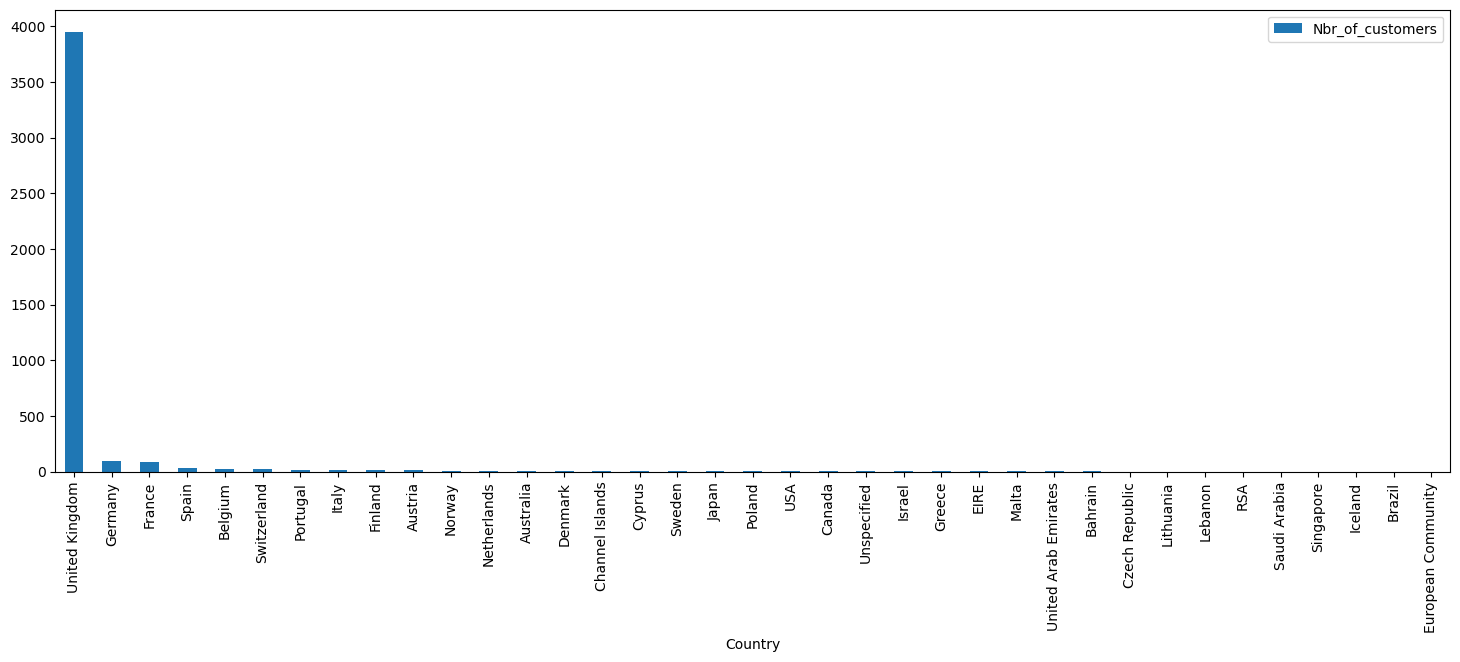

In [278]:
# Bar plot
unique_customers_per_country.plot(kind='bar', figsize = (18,6))

Le nombre de client (unique) est nettement plus élevé pour united Kingdom.

Ce diagramme en bâton montre clairement la distribution de nos clients par pays.

Il existe 4 méthodes d'analyse des données client (customer analytics):

#### l'analyse descriptive:
nous pouvons décrire le graphique en constatant que la majorité des clients de la boutique de vente en ligne viennent du Royaume-Uni. Nous pouvons également conclure que la plupart des clients de la boutique en ligne sont basés en Europe par rapport aux autres continents.

#### l'analyse diagnostique: 
nous pouvons diagnostiquer que la raison de ce grand nombre de clients venant d'Europe réside probablement dans le fait que la boutique en ligne a investi massivement dans le marketing en Europe plutôt que sur les autres continents.

#### l'analyse prédictive:
nous pouvons prédire que la boutique en ligne continuera d'attirer davantage de clients du Royaume-Uni, étant donné qu'il y existe déjà une base de clients massive.

#### l'analyse prescriptive:
nous pouvons recommander à la boutique en ligne de continuer à investir dans le marketing au Royaume-Uni, car le taux de conversion y est excellent.


À présent, passons à l'étape suivante pour comprendre comment les clients génèrent du chiffre d'affaires pour la boutique de vente en ligne.


Pour cela, nous allons calculer le montant total des transactions par mois. Commençons donc par extraire les informations de l'année et du mois à partir de la colonne InvoiceDate.

In [282]:
customer_df.head(10)

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate,Country
0,17850,536365,15.30,2010-12-01 08:26:00,United Kingdom
1,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom
2,17850,536365,22.00,2010-12-01 08:26:00,United Kingdom
3,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom
4,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom
5,17850,536365,15.30,2010-12-01 08:26:00,United Kingdom
6,17850,536365,25.50,2010-12-01 08:26:00,United Kingdom
7,17850,536366,11.10,2010-12-01 08:28:00,United Kingdom
8,17850,536366,11.10,2010-12-01 08:28:00,United Kingdom
9,13047,536367,54.08,2010-12-01 08:34:00,United Kingdom


In [283]:
# Extraire l'année (Year) et le mois (Month) de la colonne InvoiceDate
pd.to_datetime(customer_df['InvoiceDate']).apply(lambda x:x.strftime("%Y-%m"))

# Assigner notre extraction à une nouvelle colonne : InvoiceYearMonth
customer_df['InvoiceYearMonth'] = pd.to_datetime(customer_df['InvoiceDate']).apply(lambda x:x.strftime("%Y-%m"))

customer_df.head()

On applique 'goupby' pour regrouper nos données par cette nouvelle colonne InvoiceYearMonth

In [286]:
# revenu total par YearMonth
df_revenue = customer_df.groupby(['InvoiceYearMonth'])[['AmountSpent']].sum()


df_revenue.head()

,AmountSpent
InvoiceYearMonth,
2010-12,590823.760
2011-01,663815.700
2011-02,457728.550
2011-03,611036.910
2011-04,512352.871


<Axes: xlabel='InvoiceYearMonth'>

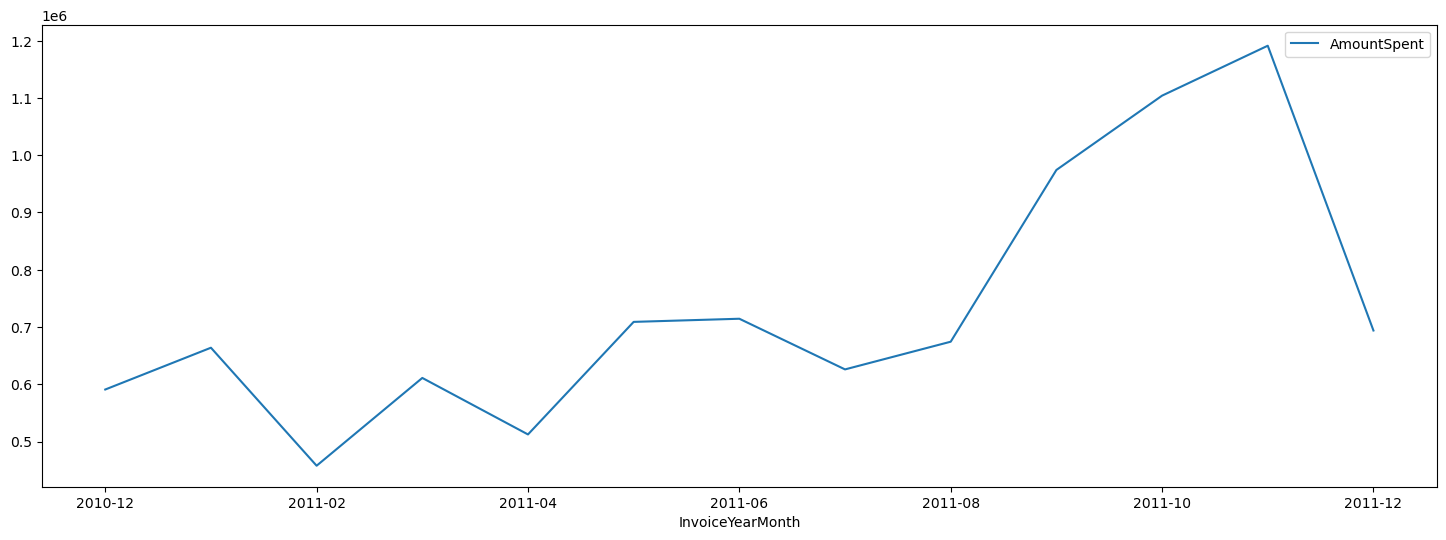

In [287]:
# faiusons un lot pour mieux voir l'évolution
df_revenue.plot(kind='line', figsize = (18,6))

On constate d'emblée que les ventes ont chuté de manière significative en décembre 2011. La boutique de vente en ligne est-elle en train de perdre des clients ?

Cherchons à en comprendre la raison.

ous pouvons connaître la date et l'heure de collecte du dernier point de données de ce DataFrame en cherchant la valeur maximale de la colonne InvoiceDate

In [289]:
#Recherche de la valeur maximale de la colonne DateTime
customer_df['InvoiceDate'].max()

'2011-12-09 12:50:00'

Ainsi, l'arrêt précoce de la collecte des données était la cause de la chute des ventes en décembre.
Détournons à présent un peu notre attention pour nous concentrer davantage sur les clients et découvrir le nombre de clients actifs mensuels pour chaque mois

In [291]:
# Création du DataFrame des clients actifs mensuels en comptant les identifiants clients uniques (Customer IDs)
df_monthly_active = customer_df.groupby('InvoiceYearMonth')[['CustomerID']].nunique()

# On renomme la colonne
df_monthly_active.columns = ['nbr_of_unique_customers']

df_monthly_active.head()

,nbr_of_unique_customers
InvoiceYearMonth,
2010-12,948
2011-01,783
2011-02,798
2011-03,1020
2011-04,899


<Axes: xlabel='InvoiceYearMonth'>

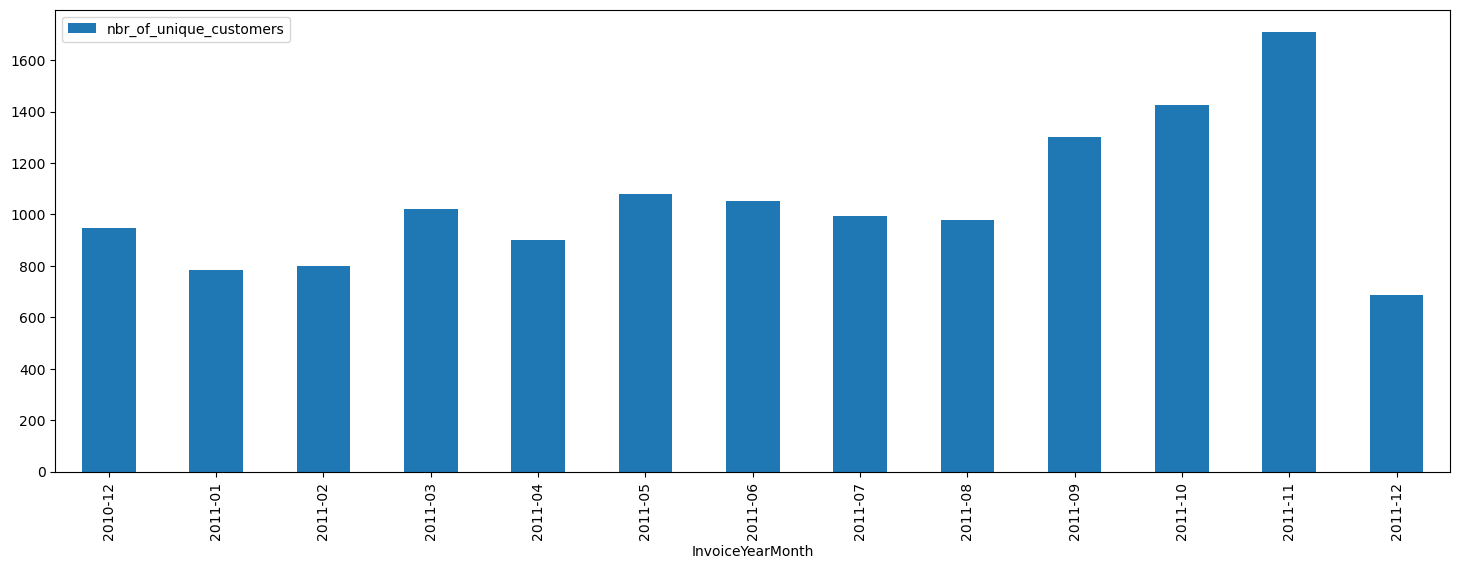

In [292]:
# représentation graphique 
df_monthly_active.plot(kind='bar', figsize = (18,6))

On peut mieux voir l'évolution avec une cette courbe de tendance ou trendline sur le graphe suivant.

Text(0, 0.5, 'Nombre de clients uniques')

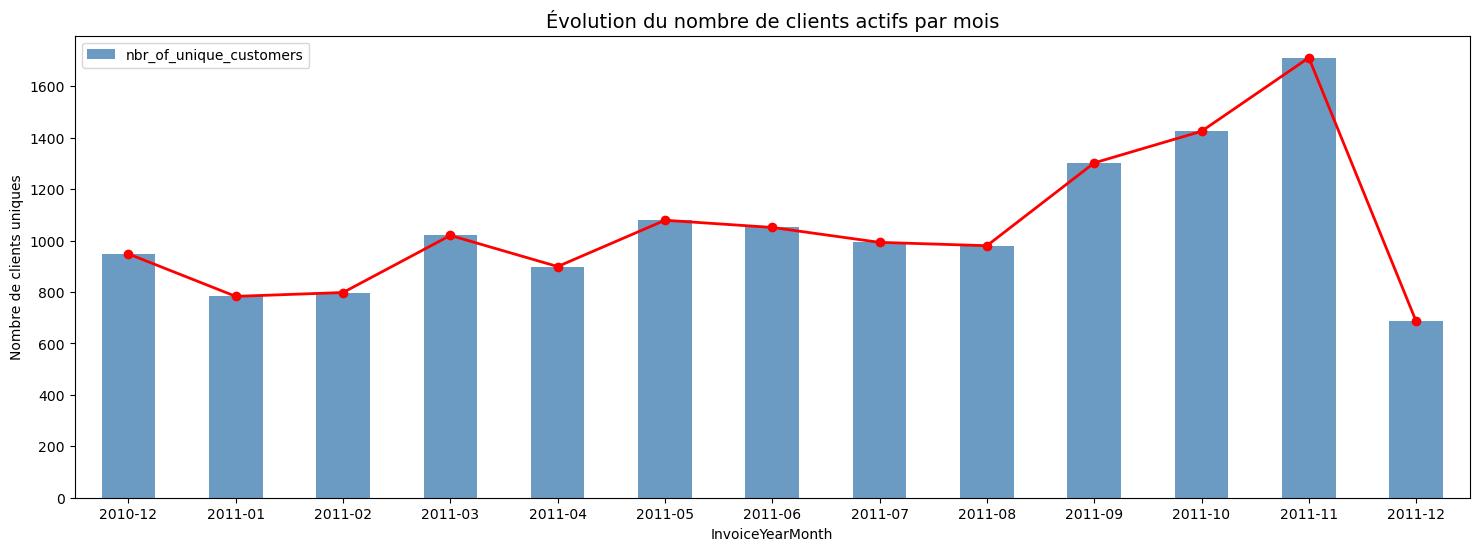

In [294]:
# le diagramme
ax = df_monthly_active.plot(kind='bar', figsize=(18, 6), color='#4682B4', alpha=0.8)

# la courbe
# 'reset_index().index' permet d'utiliser les positions numériques (0, 1, 2...) pour aligner parfaitement la courbe avec les barres
df_monthly_active.reset_index()['nbr_of_unique_customers'].plot(
    kind='line', 
    marker='o',      # Ajoute un point sur chaque barre
    color='red',     # Couleur de la courbe
    linewidth=2,     # Épaisseur de la ligne
    ax=ax            # Utilise les mêmes axes que le graphique en barres
)


ax.set_title("Évolution du nombre de clients actifs par mois", fontsize=14)
ax.set_ylabel("Nombre de clients uniques")

In [295]:
#customer_df.head()

On peut constater que la croissance du nombre de clients actifs par mois suit une tendance similaire à celle du chiffre d'affaires total mensuel. Nous pouvons donc supposer que la croissance du nombre de clients actifs est probablement la cause de la croissance du chiffre d'affaires total généré par mois. 


## La récence, de la fréquence et de la valeur monétaire des clients (Analyse RFM)

Il s'agira ioci d'essayer de répondre à ces différentes questions:

- **À quand remonte le dernier achat de chaque client unique ? (Récence)**

- **Combien de fois chaque client unique a-t-il effectué un achat ? (Fréquence)**

- **Combien chaque client unique a-t-il dépensé au total ? (Valeur monétaire)**

- **À quand remonte le dernier achat de chaque client unique ? (Récence)**

Nous allons créer une nouvelle variable (Feature) qui nous permettra de déterminer la récence de l'achat effectué par chaque client unique. Pour cela, nous prendrons la date du 09/12/2011 comme point d'observation, et nous calculerons le nombre de jours écoulés depuis le dernier achat d'un client par rapport à ce point d'observation.

Ainsi, si la date du dernier achat d'un client est le 01/12/2011, le nombre de jours écoulés depuis le point d'observation sera calculé comme suit : (09/12/2011) - (01/12/2011) = 8 jours.

Trions maintenant le DataFrame en fonction de la colonne InvoiceDate.

In [301]:
# Tri de la base de données selon la variable InvoiceDate
customer_df.sort_values('InvoiceDate', inplace=True)

In [302]:
customer_df.head()

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate,Country,InvoiceYearMonth
0,17850,536365,15.30,2010-12-01 08:26:00,United Kingdom,2010-12
1,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom,2010-12
2,17850,536365,22.00,2010-12-01 08:26:00,United Kingdom,2010-12
3,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom,2010-12
4,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom,2010-12


In [303]:
# on supprime toutes les lignes de chaque CustomerID sauf la dernière, qui n'est rien d'autre que le dernier achat 

customer_df_last = customer_df.drop_duplicates('CustomerID', keep='last').reset_index(drop=True)
customer_df_last.head()

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate,Country,InvoiceYearMonth
0,18074,536384,102.00,2010-12-01 09:53:00,United Kingdom,2010-12
1,13747,536393,79.60,2010-12-01 10:37:00,United Kingdom,2010-12
2,12791,536403,15.00,2010-12-01 11:27:00,Netherlands,2010-12
3,17908,536409,0.42,2010-12-01 11:45:00,United Kingdom,2010-12
4,16583,536420,20.40,2010-12-01 12:03:00,United Kingdom,2010-12


In [304]:
#La récence de chaque client par rapport au 09/12/2011.
customer_df_last['Recence'] = pd.to_datetime(customer_df_last['InvoiceDate'].max()) - pd.to_datetime(customer_df_last['InvoiceDate'])
customer_df_last.head(5)

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate,Country,InvoiceYearMonth,Recence
0,18074,536384,102.00,2010-12-01 09:53:00,United Kingdom,2010-12,373 days 02:57:00
1,13747,536393,79.60,2010-12-01 10:37:00,United Kingdom,2010-12,373 days 02:13:00
2,12791,536403,15.00,2010-12-01 11:27:00,Netherlands,2010-12,373 days 01:23:00
3,17908,536409,0.42,2010-12-01 11:45:00,United Kingdom,2010-12,373 days 01:05:00
4,16583,536420,20.40,2010-12-01 12:03:00,United Kingdom,2010-12,373 days 00:47:00


extraction uniquement le nombre de jours de la colonne Recence (Récence) ainsi que le CustomerID.

In [306]:
# Extracting only the day value
customer_df_last['Recence'] = customer_df_last['Recence'].dt.days

# Selecting only the CustomerID and Recency column
customer_df_last = customer_df_last[['CustomerID', 'Recence']]

# Looking at the first five rows
customer_df_last.head()

,CustomerID,Recence
0,18074,373
1,13747,373
2,12791,373
3,17908,373
4,16583,373


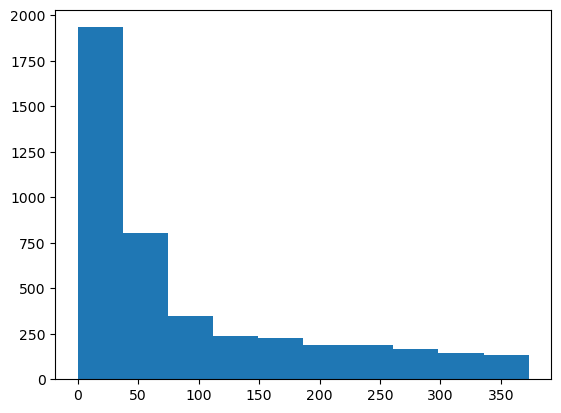

In [307]:
# représentation graphique par un histogram
import matplotlib.pyplot as plt
plt.hist(customer_df_last['Recence']);

On constate que la majorité des clients ont effectué un achat au cours des 50 derniers jours, ce qui signifie que la plupart d'entre eux sont actifs

- **Combien de fois chaque client unique a-t-il effectué un achat ? (Fréquence)**

Nous allons déterminer la fréquence d'achat de chaque client unique. Pour ce faire, nous compterons le nombre de lignes présentes dans les données transactionnelles nettoyées pour chaque client unique, étant donné que chaque ligne correspond à un achat effectué par un client.

In [311]:
customer_df.head()

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate,Country,InvoiceYearMonth
0,17850,536365,15.30,2010-12-01 08:26:00,United Kingdom,2010-12
1,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom,2010-12
2,17850,536365,22.00,2010-12-01 08:26:00,United Kingdom,2010-12
3,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom,2010-12
4,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom,2010-12


Calculons le nombre de fois que chaque client a passé une commande

In [313]:
df_frequence = customer_df['CustomerID'].value_counts().reset_index()
df_frequence.head()

,CustomerID,count
0,17841,7983
1,14911,5903
2,14096,5128
3,12748,4642
4,14606,2782


On peut constater que le client avec l'ID 17841 a passé 7983 fois de commande.

In [315]:
#customer_df.head()

Faisons un merge entre df_frequence et customer_df_last sur la base de la colonne CustomerID pour avoir une nouvelle table customer_df_merge

In [317]:
customer_df_merge = pd.merge(customer_df_last, df_frequence, on='CustomerID')
customer_df_merge.head()

,CustomerID,Recence,count
0,18074,373,13
1,13747,373,1
2,12791,373,2
3,17908,373,58
4,16583,373,14


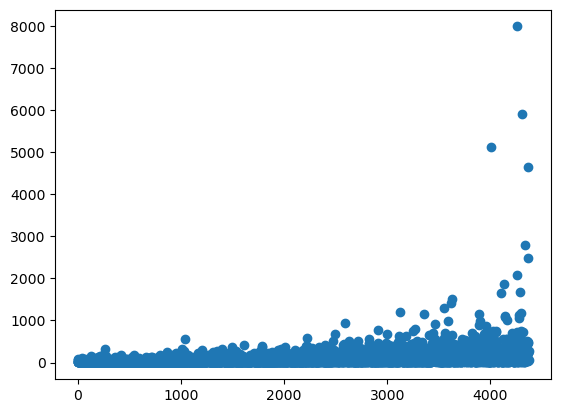

In [318]:
#faisons un nuage de points pour la variable count visualiser la distribution
plt.scatter(range(customer_df_merge.shape[0]), customer_df_merge['count'])

On peut observer que la majorité des clients uniques ont effectué entre 1 et 1000 achats dans la boutique de vente en ligne. 
Il existe également quelques clients atypiques (ou "outliers") ayant acheté des articles sur la boutique plus de 1000 fois.

- **Combien chaque client unique a-t-il dépensé au total ? (Valeur monétaire)**

On va essayer de répondre à la question suivante : quel est le montant total dépensé par chaque client unique ? (Valeur Monétaire)

In [322]:
customer_df.head()

,CustomerID,InvoiceNo,AmountSpent,InvoiceDate,Country,InvoiceYearMonth
0,17850,536365,15.30,2010-12-01 08:26:00,United Kingdom,2010-12
1,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom,2010-12
2,17850,536365,22.00,2010-12-01 08:26:00,United Kingdom,2010-12
3,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom,2010-12
4,17850,536365,20.34,2010-12-01 08:26:00,United Kingdom,2010-12


In [323]:
# montant total dépensé par client
customer_df_montant= customer_df.groupby("CustomerID")["AmountSpent"].sum().reset_index()

#on renomme la nouvelle colonne en Revenu
customer_df_montant.rename(columns = {"AmountSpent" : "Revenu"}, inplace=True)

customer_df_montant.head()

,CustomerID,Revenu
0,12346,154367.20
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


In [324]:
# on fait le merge avec la base customer_df_last 
customer_df_montant_merge = pd.merge(customer_df_last,customer_df_montant,  on='CustomerID')
customer_df_montant_merge.head()

,CustomerID,Recence,Revenu
0,18074,373,489.60
1,13747,373,79.60
2,12791,373,192.60
3,17908,373,243.28
4,16583,373,233.45


In [325]:
#customer_df_merge.head()

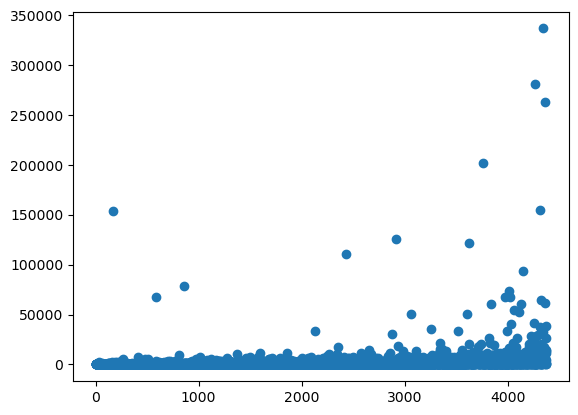

In [326]:
#faisons un nuage de points pour la variable Revenu visualiser la distribution
plt.scatter(range(df_frequence.shape[0]), customer_df_montant_merge['Revenu'])

On peut constater que la plupart des clients ont effectué des achats pour un montant inférieur à 50 000, mais il existe quelques cas atypiques (outliers) dont les achats dépassent les 50 000.

In [328]:
df_frequence.head()

,CustomerID,count
0,17841,7983
1,14911,5903
2,14096,5128
3,12748,4642
4,14606,2782


In [329]:
#merge avec df_frequence
customer_df_agregat = pd.merge(customer_df_merge,customer_df_montant,  on='CustomerID')
customer_df_agregat.head()

,CustomerID,Recence,count,Revenu
0,18074,373,13,489.60
1,13747,373,1,79.60
2,12791,373,2,192.60
3,17908,373,58,243.28
4,16583,373,14,233.45


### Profilage et segmentation des clients

In [331]:
#Importation librarie
from sklearn.cluster import KMeans

In [332]:
customer_df_agregat.head()


,CustomerID,Recence,count,Revenu
0,18074,373,13,489.60
1,13747,373,1,79.60
2,12791,373,2,192.60
3,17908,373,58,243.28
4,16583,373,14,233.45


In [333]:
customer_df_agregat.shape

(4372, 4)

In [334]:
# initialisation de 4 clusters
Kmeans = KMeans(n_clusters=4)

In [335]:
Kmeans.fit(customer_df_agregat[['Recence']])

KMeans(n_clusters=4)

   #### segmentation basée sur notre variable Recence

In [337]:
# Prédiction et affectation des clusters
customer_df_agregat['RecenceCluster'] = Kmeans.predict(customer_df_agregat[['Recence']])
customer_df_agregat.head()

,CustomerID,Recence,count,Revenu,RecenceCluster
0,18074,373,13,489.60,1
1,13747,373,1,79.60,1
2,12791,373,2,192.60,1
3,17908,373,58,243.28,1
4,16583,373,14,233.45,1


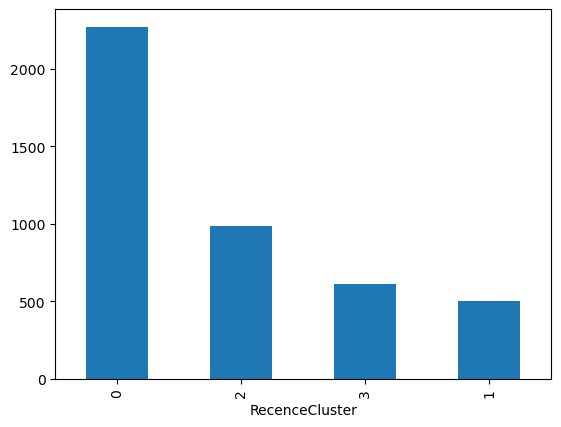

In [338]:
# regardons la distribution de la variable RecenceCluster

customer_df_agregat['RecenceCluster'].value_counts().plot.bar()
plt.show()

On constate que les données ont été réparties en différents clusters, à savoir 0, 1, 2 et 3. 
Cependant, l'algorithme K-Means n'établit pas de classement hiérarchique entre les clusters par défaut.
Nous allons donc les ordonner en fonction de leurs valeurs moyennes.

On va grouper nos données par cluster et trouver la moyenne de chaque groupe de cluster

In [341]:
df_new = customer_df_agregat.groupby("RecenceCluster")["Recence"].mean().reset_index()
df_new.head()

,RecenceCluster,Recence
0,0,19.036532
1,1,308.968317
2,2,83.391260
3,3,191.032733


Il faut noter que dans ce nouvel dataframe, la colonne "Recence" représente la moyenne des classes de clusters. On va donc la renommer.

In [343]:
df_new.rename(columns={"Recence": "MoyenneRecence"}, inplace=True)
df_new = df_new.sort_values(by= "MoyenneRecence", ascending= False).reset_index(drop=True)
df_new

,RecenceCluster,MoyenneRecence
0,1,308.968317
1,3,191.032733
2,2,83.391260
3,0,19.036532


In [344]:
df_new['ScoreRecence'] = df_new.index
df_new.head()

,RecenceCluster,MoyenneRecence,ScoreRecence
0,1,308.968317,0
1,3,191.032733,1
2,2,83.391260,2
3,0,19.036532,3


Faison un merge de df_new et de customer_df_agregat

In [346]:
# Create a final dataframe by merging our original dataframe and the new dataframe
df_user = pd.merge(customer_df_agregat, df_new[["RecenceCluster",'ScoreRecence']], on= "RecenceCluster")

# Remove the column for cluster
df_user.drop("RecenceCluster", axis= 1, inplace=True)

df_user.head()

,CustomerID,Recence,count,Revenu,ScoreRecence
0,18074,373,13,489.60,0
1,13747,373,1,79.60,0
2,12791,373,2,192.60,0
3,17908,373,58,243.28,0
4,16583,373,14,233.45,0


In [347]:
df_user.groupby('ScoreRecence')['Recence'].describe()

,count,mean,std,min,25%,50%,75%,max
ScoreRecence,,,,,,,,
0,505.0,308.968317,39.095414,251.0,274.0,305.0,351.0,373.0
1,611.0,191.032733,32.225266,138.0,164.0,189.0,217.0,250.0
2,984.0,83.391260,23.837368,52.0,63.0,77.0,101.0,137.0
3,2272.0,19.036532,14.683479,0.0,7.0,17.0,30.0,51.0


### Profilage et segmentation des clients basées sur la variable Frequence

In [349]:
df_user.head()

,CustomerID,Recence,count,Revenu,ScoreRecence
0,18074,373,13,489.60,0
1,13747,373,1,79.60,0
2,12791,373,2,192.60,0
3,17908,373,58,243.28,0
4,16583,373,14,233.45,0


In [350]:
#on va renommer la colonne "count" en "Frequence"
df_user.rename(columns={"count": "Frequence"}, inplace=True)

In [352]:
# Fit du modèle
Kmeans.fit(df_user[['Frequence']])

KMeans(n_clusters=4)

In [356]:
#Prédiction et affectation des clusters
df_user['ClusterFrequence'] = Kmeans.predict(df_user[['Frequence']])

<Axes: xlabel='ClusterFrequence'>

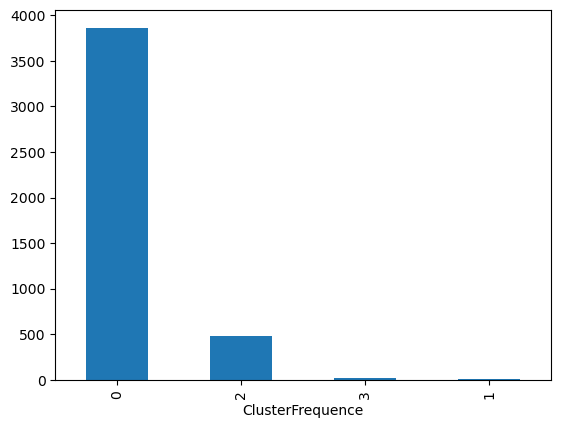

In [358]:
#plot pour voir la distribution de ClusterFrequence
df_user['ClusterFrequence'].value_counts().plot.bar()

In [360]:
# ordonner les clusters
def order_cluster(cluster_name, column_name, df, ascending):
    """
    Order clusters based on their mean values.
    """
    

    #groupé notre base poar rapport à la variable cluster_name et calcul des moyennes
    df_new = df.groupby(cluster_name)[column_name].mean().reset_index()
    
    # Tri
    df_new = df_new.sort_values(by=column_name,ascending=ascending).reset_index(drop=True)
    
    #création de new_column 
    new_column = column_name + "Score"
    df_new[new_column] = df_new.index
    
    # Create a final dataframe by merging our original dataframe and the new dataframe
    df_final = pd.merge(df,df_new[[cluster_name, new_column]], on=cluster_name)
    
    # Remove the column for cluster
    df_final.drop(cluster_name, axis= 1, inplace=True)
    
    return df_final

In [368]:
df_user.head()


,CustomerID,Recence,Frequence,Revenu,ScoreRecence,FrequenceScore
0,18074,373,13,489.60,0,0
1,13747,373,1,79.60,0,0
2,12791,373,2,192.60,0,0
3,17908,373,58,243.28,0,0
4,16583,373,14,233.45,0,0


In [372]:
df_user.groupby('FrequenceScore')['Frequence'].describe()

,count,mean,std,min,25%,50%,75%,max
FrequenceScore,,,,,,,,
0,3862.0,49.753755,44.812998,1.0,15.0,34.0,73.0,189.0
1,482.0,329.105809,132.667903,190.0,228.0,286.0,393.5,803.0
2,24.0,1349.750000,508.637759,872.0,1003.5,1156.0,1541.0,2782.0
3,4.0,5914.000000,1473.845537,4642.0,5006.5,5515.5,6423.0,7983.0


### Profilage et segmentation des clients basées sur le Revenu

In [383]:
Kmeans.fit(df_user[['Revenu']])
df_user['ClusterRevenu'] = Kmeans.predict(df_user[['Revenu']])
df_user.head()

,CustomerID,Recence,Frequence,Revenu,ScoreRecence,FrequenceScore,ClusterRevenu
0,18074,373,13,489.60,0,0,0
1,13747,373,1,79.60,0,0,0
2,12791,373,2,192.60,0,0,0
3,17908,373,58,243.28,0,0,0
4,16583,373,14,233.45,0,0,0


<Axes: xlabel='ClusterRevenu'>

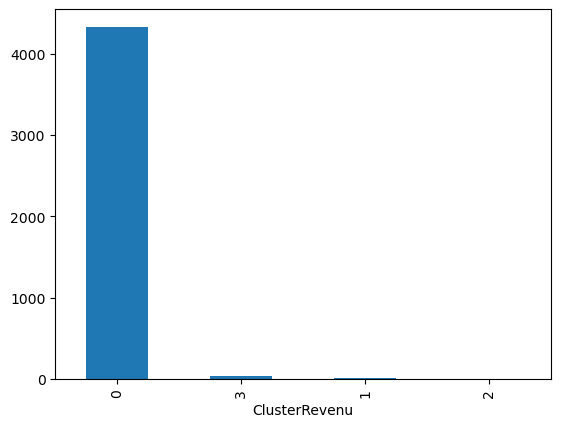

In [385]:
df_user['ClusterRevenu'].value_counts().plot.bar()

In [393]:
df_user.head()

,CustomerID,Recence,Frequence,Revenu,ScoreRecence,FrequenceScore,RevenuScore
0,18074,373,13,489.60,0,0,0
1,13747,373,1,79.60,0,0,0
2,12791,373,2,192.60,0,0,0
3,17908,373,58,243.28,0,0,0
4,16583,373,14,233.45,0,0,0


In [399]:
df_user.groupby('RevenuScore')['Revenu'].describe()

,count,mean,std,min,25%,50%,75%,max
RevenuScore,,,,,,,,
0,4333.0,1463.977051,2287.153138,0.00,307.1600,669.140,1638.5300,21834.77
1,29.0,46034.246897,16436.726540,26205.97,32367.2800,40894.950,60681.7200,79183.50
2,6.0,126996.646667,24136.985321,93999.38,113636.5825,123739.365,147301.3025,155077.50
3,4.0,270590.160000,55754.876799,201619.41,247561.9350,271899.565,294927.7900,336942.10


Nous avons fait le profilage et la segmentation de nos clients. Ceci nous a permis
de trouver les scores pour nos trois variables RFM. Nous allons maintenant combiner ces
trois scores pour en faire un score global, lequel nous aiderait pour prendre des décisions

In [414]:
# Calculate overall score
df_user.rename(columns={"FrequenceScore": "ScoreFrequence", "RevenuScore":"ScoreRevenu"}, inplace=True)
df_user['RFMScoreGlobal'] = df_user['ScoreRecence'] + df_user['ScoreFrequence'] + df_user['ScoreRevenu']

In [410]:
df_user.head()

,CustomerID,Recence,Frequence,Revenu,ScoreRecence,ScoreFrequence,ScoreRevenu,OverallRFMScore
0,18074,373,13,489.60,0,0,0,0
1,13747,373,1,79.60,0,0,0,0
2,12791,373,2,192.60,0,0,0,0
3,17908,373,58,243.28,0,0,0,0
4,16583,373,14,233.45,0,0,0,0
5,17968,373,85,277.35,0,0,0,0
6,14729,373,71,313.49,0,0,0,0
7,14237,372,9,161.00,0,0,0,0
8,15350,372,5,115.65,0,0,0,0
9,15165,372,27,487.75,0,0,0,0


In [416]:
df_user["RFMScoreGlobal"].unique()

array([0, 2, 1, 3, 4, 5, 6, 7, 8], dtype=int64)

ce résultat montre qu'on a 9 différents scores. Voyons la distribution de la variable 
RFMScoreGlobal

<Axes: xlabel='RFMScoreGlobal'>

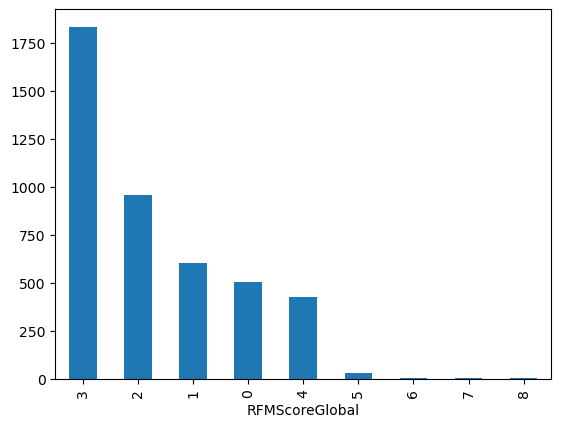

In [421]:
df_user["RFMScoreGlobal"].value_counts().plot.bar()

In [425]:
df_user.groupby('RFMScoreGlobal')[['Recence','Frequence','Revenu']].mean()

,Recence,Frequence,Revenu
RFMScoreGlobal,,,
0,308.960159,22.324701,384.104602
1,191.642975,33.105785,617.794514
2,84.678161,45.568443,1256.486752
3,21.950382,69.848964,1418.652672
4,12.607477,329.408879,5713.936192
5,7.933333,858.900000,21995.071667
6,9.285714,1157.857143,111055.351429
7,3.142857,3004.714286,119012.630000
8,0.500000,3994.000000,218000.260000


La majorité des données semble présenter un Score RFM de 3, suivi par les scores 2 et 1.

Un Score RFM faible signifie que les clients ont une faible récence (achats anciens), sont moins fréquents et génèrent peu de revenus.

Un Score RFM élevé signifie que les clients ont une récence élevée (achats récents), sont plus fréquents et génèrent une valeur de revenus plus importante pour nous.

### Segmentation basée sur le score global

Nous allons diviser (segmenter) nos clients en trois:
- Low-value
- Mid-value
- High-value

In [430]:
df_user['Segment'] = 'Low-Value'
df_user.loc[df_user['RFMScoreGlobal']>2, 'Segment'] = 'Mid-Value' 
df_user.loc[df_user['RFMScoreGlobal']>4, 'Segment'] = 'High-Value' 

In [432]:
df_user.head()

,CustomerID,Recence,Frequence,Revenu,ScoreRecence,ScoreFrequence,ScoreRevenu,OverallRFMScore,RFMScoreGlobal,Segment
0,18074,373,13,489.60,0,0,0,0,0,Low-Value
1,13747,373,1,79.60,0,0,0,0,0,Low-Value
2,12791,373,2,192.60,0,0,0,0,0,Low-Value
3,17908,373,58,243.28,0,0,0,0,0,Low-Value
4,16583,373,14,233.45,0,0,0,0,0,Low-Value


<Axes: xlabel='Segment'>

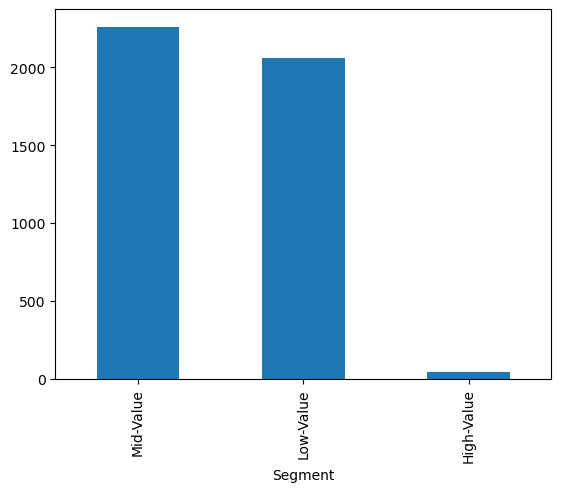

In [434]:
df_user['Segment'].value_counts().plot.bar()

On constate que nous disposons d'une grande quantité de clients à 
valeur faible et intermédiaire, mais de très peu de clients à haute 
valeur ajoutée. Cette segmentation nous aide à déterminer les types 
de stratégies et d'approches nécessaires pour améliorer les ventes et
les bénéfices, ce qui nous permettra d'augmenter le nombre de clients à
haute valeur et de favoriser leur 
fidélisation.

Nous avons ainsi segmenté nos clients avec succès. Ces segments 
peuvent désormais nous aider dans divers processus de développement 
de l'entreprise, tels que les ventes et le 
marketing.

La direction peut se baser sur cette étude de segmentation pour faire les promotions 
sur des segments de clients, cibler quelle catégorie de client pour quel type de promotion. 